# Pattern Recognition Assigment 02
Implementasi dari:
- **Histogram of Energy (HoE)**
- **Histogram of Zero Crossing Rate (HoZCR)**
- **Histogram of Energy Entropy (HoEE)**

Sinyal audio dibagi ke dalam **frame-frame pendek**, kemudian fitur dihitung per frame, lalu distribusinya divisualisasikan sebagai histogram.

---
## 1. Import Library Dasar & Generate Sinyal Audio Sintetis

Kita hanya menggunakan library dasar seperti `numpy` ( untuk komputasi numerik) dan `matplotlib` (untuk visualisasi). Sinyal audio dibuat secara sintetis dari beberapa komponen frekuensi + noise agar menyerupai sinyal nyata.

Sinyal berhasil dibuat:
  Sample rate : 22050 Hz
  Durasi      : 3.0 s
  Jumlah sampel: 66150


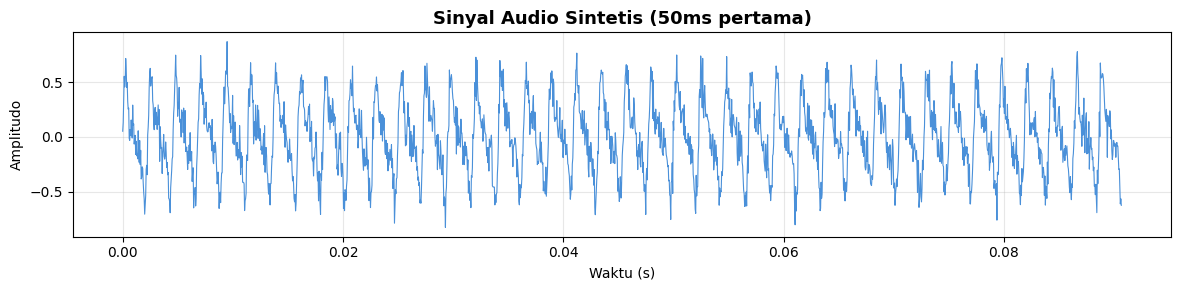

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Parameter sinyal
SAMPLE_RATE = 22050        # Hz
DURATION    = 3.0          # detik
N_SAMPLES   = int(SAMPLE_RATE * DURATION)

# Generate sinyal sintetis
np.random.seed(42)
t = np.linspace(0, DURATION, N_SAMPLES, endpoint=False)

# Gabungan beberapa frekuensi + noise untuk menyerupai suara nyata
signal = (
    0.5  * np.sin(2 * np.pi * 440  * t) +   # nada A4
    0.3  * np.sin(2 * np.pi * 880  * t) +   # harmonik oktaf
    0.2  * np.sin(2 * np.pi * 1320 * t) +   # harmonik ke-3
    0.15 * np.random.randn(N_SAMPLES)        # noise
)

# Normalisasi ke [-1, 1]
signal = signal / np.max(np.abs(signal))

print(f"Sinyal berhasil dibuat:")
print(f"  Sample rate : {SAMPLE_RATE} Hz")
print(f"  Durasi      : {DURATION} s")
print(f"  Jumlah sampel: {N_SAMPLES}")

# Plot sinyal
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t[:2000], signal[:2000], color='#4A90D9', lw=0.8)
ax.set_title('Sinyal Audio Sintetis (50ms pertama)', fontsize=13, fontweight='bold')
ax.set_xlabel('Waktu (s)')
ax.set_ylabel('Amplitudo')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Framing Sinyal

Sebelum menghitung fitur, sinyal dipecah menjadi **frame-frame pendek** yang saling tumpang tindih (*overlapping frames*).

| Parameter | Nilai | Keterangan |
|-----------|-------|------------|
| `frame_size` | 1024 sampel | ~46ms pada 22050 Hz |
| `hop_size` | 512 sampel | 50% overlap |

$$\text{jumlah frame} = \left\lfloor \frac{N - \text{frame\_size}}{\text{hop\_size}} \right\rfloor + 1$$

Hasil framing:
  Jumlah frame : 128
  Ukuran frame : 1024 sampel
  Durasi frame : 46.4 ms


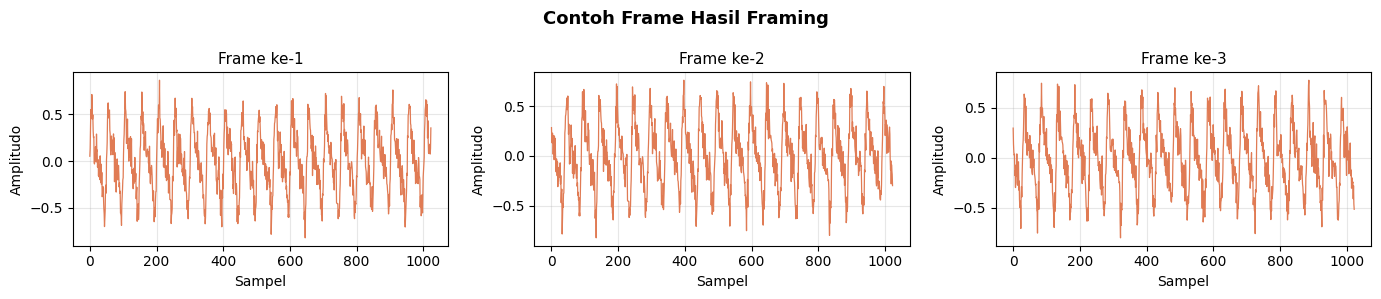

In [14]:
FRAME_SIZE = 1024   # sampel per frame
HOP_SIZE   = 512    # langkah antar frame (50% overlap)

def frame_signal(x, frame_size, hop_size):
    n_frames = (len(x) - frame_size) // hop_size + 1
    frames = np.zeros((n_frames, frame_size))
    for i in range(n_frames):
        start = i * hop_size
        frames[i] = x[start : start + frame_size]
    return frames

frames = frame_signal(signal, FRAME_SIZE, HOP_SIZE)

print(f"Hasil framing:")
print(f"  Jumlah frame : {frames.shape[0]}")
print(f"  Ukuran frame : {frames.shape[1]} sampel")
print(f"  Durasi frame : {FRAME_SIZE / SAMPLE_RATE * 1000:.1f} ms")

# Visualisasi beberapa frame
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for idx, ax in enumerate(axes):
    ax.plot(frames[idx], color='#E07B54', lw=0.9)
    ax.set_title(f'Frame ke-{idx+1}', fontsize=11)
    ax.set_xlabel('Sampel')
    ax.set_ylabel('Amplitudo')
    ax.grid(True, alpha=0.3)
plt.suptitle('Contoh Frame Hasil Framing', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Histogram of Energy (HoE)

### Konsep
**Energy** suatu frame mengukur seberapa kuat sinyal dalam frame tersebut. Rumusnya:

$$E_i = \frac{1}{N} \sum_{n=0}^{N-1} x_i[n]^2$$

di mana $N$ adalah jumlah sampel dalam frame, dan $x_i[n]$ adalah sampel ke-$n$ pada frame ke-$i$.

**Histogram of Energy** kemudian menghitung distribusi nilai energi dari seluruh frame — berguna untuk membedakan segmen senyap vs. bersuara.

In [15]:
def compute_energy(frames):
    """
    Hitung Short-Time Energy (STE) untuk setiap frame.
    E_i = (1/N) * sum(x_i[n]^2)
    """
    n_frames, frame_size = frames.shape
    energies = np.zeros(n_frames)
    for i in range(n_frames):
        total = 0.0
        for n in range(frame_size):
            total += frames[i, n] ** 2        # x^2
        energies[i] = total / frame_size      # rata-rata
    return energies

energies = compute_energy(frames)

print(f"Energy — statistik:")
print(f"  Min  : {energies.min():.6f}")
print(f"  Max  : {energies.max():.6f}")
print(f"  Mean : {energies.mean():.6f}")

Energy — statistik:
  Min  : 0.096414
  Max  : 0.108144
  Mean : 0.101912


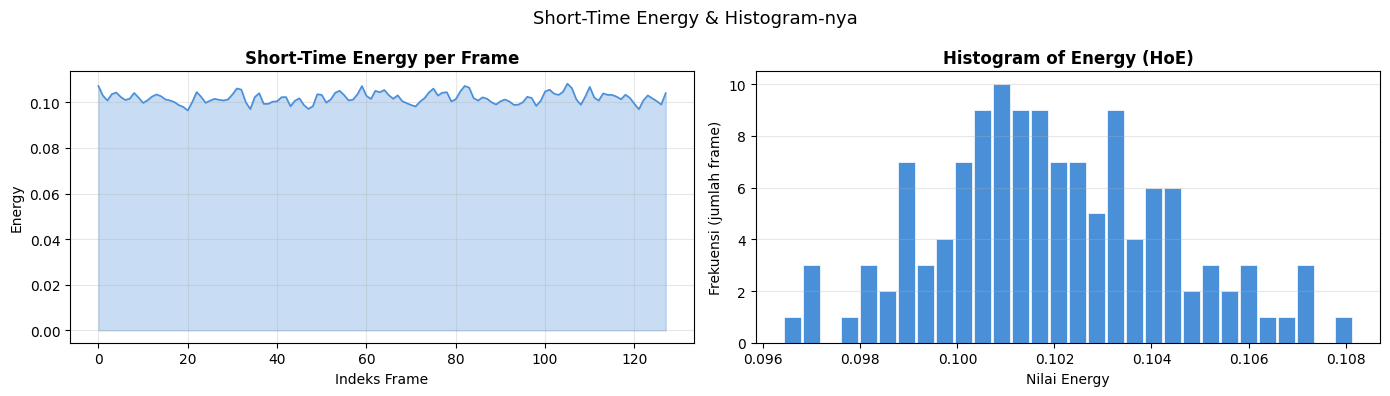

Histogram of Energy berhasil dihitung (30 bin).


In [16]:
def manual_histogram(data, n_bins):
    """
    Membuat histogram secara manual.

    Returns
    -------
    counts     : jumlah data di setiap bin
    bin_edges  : tepi-tepi bin (panjang n_bins+1)
    """
    d_min = min(data)
    d_max = max(data)
    bin_width = (d_max - d_min) / n_bins

    counts = [0] * n_bins
    for val in data:
        if val == d_max:                       # nilai maksimum masuk bin terakhir
            idx = n_bins - 1
        else:
            idx = int((val - d_min) / bin_width)
        counts[idx] += 1

    bin_edges = [d_min + i * bin_width for i in range(n_bins + 1)]
    return counts, bin_edges

N_BINS = 30
energy_counts, energy_edges = manual_histogram(energies.tolist(), N_BINS)



# Visualisasi
bin_centers = [(energy_edges[i] + energy_edges[i+1]) / 2 for i in range(N_BINS)]
bin_width   = energy_edges[1] - energy_edges[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Panel kiri: energy per frame
axes[0].plot(energies, color='#4A90D9', lw=1.2)
axes[0].fill_between(range(len(energies)), energies, alpha=0.3, color='#4A90D9')
axes[0].set_title('Short-Time Energy per Frame', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Indeks Frame')
axes[0].set_ylabel('Energy')
axes[0].grid(True, alpha=0.3)

# Panel kanan: histogram of energy
axes[1].bar(bin_centers, energy_counts, width=bin_width * 0.9,
            color='#4A90D9', edgecolor='white', linewidth=0.5)
axes[1].set_title('Histogram of Energy (HoE)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Nilai Energy')
axes[1].set_ylabel('Frekuensi (jumlah frame)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Short-Time Energy & Histogram-nya', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Histogram of Energy berhasil dihitung ({N_BINS} bin).")

## 4. Histogram of Zero Crossing Rate (HoZCR)

### Konsep
**Zero Crossing Rate (ZCR)** adalah laju seberapa sering sinyal menyilang nilai nol dalam satu frame:

$$\text{ZCR}_i = \frac{1}{N-1} \sum_{n=1}^{N-1} \mathbf{1}\bigl[\text{sign}(x_i[n]) \neq \text{sign}(x_i[n-1])\bigr]$$

ZCR tinggi → sinyal berfrekuensi tinggi (contoh: desisan, noise).  
ZCR rendah → sinyal berfrekuensi rendah atau senyap.

In [17]:
def compute_zcr(frames):
    n_frames, frame_size = frames.shape
    zcr = np.zeros(n_frames)
    for i in range(n_frames):
        crossings = 0
        for n in range(1, frame_size):
            # Deteksi perubahan tanda: perkalian negatif = tanda berbeda
            if frames[i, n] * frames[i, n - 1] < 0:
                crossings += 1
        zcr[i] = crossings / (frame_size - 1)
    return zcr

zcr_values = compute_zcr(frames)

print(f"ZCR — statistik:")
print(f"  Min  : {zcr_values.min():.6f}")
print(f"  Max  : {zcr_values.max():.6f}")
print(f"  Mean : {zcr_values.mean():.6f}")

ZCR — statistik:
  Min  : 0.113392
  Max  : 0.171065
  Mean : 0.139663


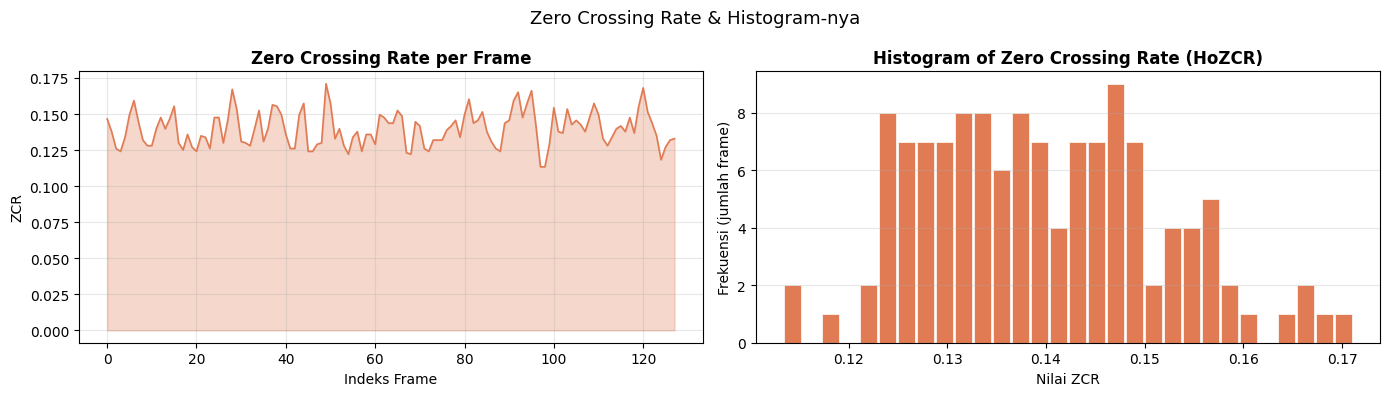

Histogram of ZCR berhasil dihitung (30 bin).


In [18]:
# Visualisasi
zcr_counts, zcr_edges = manual_histogram(zcr_values.tolist(), N_BINS)
zcr_centers = [(zcr_edges[i] + zcr_edges[i+1]) / 2 for i in range(N_BINS)]
zcr_bw      = zcr_edges[1] - zcr_edges[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(zcr_values, color='#E07B54', lw=1.2)
axes[0].fill_between(range(len(zcr_values)), zcr_values, alpha=0.3, color='#E07B54')
axes[0].set_title('Zero Crossing Rate per Frame', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Indeks Frame')
axes[0].set_ylabel('ZCR')
axes[0].grid(True, alpha=0.3)

axes[1].bar(zcr_centers, zcr_counts, width=zcr_bw * 0.9,
            color='#E07B54', edgecolor='white', linewidth=0.5)
axes[1].set_title('Histogram of Zero Crossing Rate (HoZCR)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Nilai ZCR')
axes[1].set_ylabel('Frekuensi (jumlah frame)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Zero Crossing Rate & Histogram-nya', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Histogram of ZCR berhasil dihitung ({N_BINS} bin).")

## 5. Histogram of Energy Entropy (HoEE)

### Konsep
**Energy Entropy** mengukur seberapa *tidak merata* (irregular) distribusi energi di dalam satu frame. Tiap frame dibagi lagi menjadi **sub-frame**, energi tiap sub-frame dinormalisasi menjadi distribusi probabilitas $p_k$, lalu dihitung entropi Shannon:

$$H_i = -\sum_{k=1}^{K} p_k \log_2(p_k), \quad p_k = \frac{E_k^{\text{sub}}}{\sum_j E_j^{\text{sub}}}$$

- **Entropi tinggi** → energi tersebar merata → sinyal noise atau kompleks.  
- **Entropi rendah** → energi terkonsentrasi di sub-frame tertentu → sinyal tonal/periodik.

In [19]:
def compute_energy_entropy(frames, n_subframes=8):
    """
    Hitung Energy Entropy untuk setiap frame.

    Langkah per frame:
      1. Bagi frame menjadi K sub-frame
      2. Hitung energi tiap sub-frame
      3. Normalisasi → distribusi probabilitas p_k
      4. Hitung entropi Shannon: H = -sum(p_k * log2(p_k))

    Parameters
    ----------
    frames      : ndarray (n_frames, frame_size)
    n_subframes : jumlah sub-frame (K)
    """
    n_frames, frame_size = frames.shape
    sub_len = frame_size // n_subframes    # panjang tiap sub-frame
    entropy = np.zeros(n_frames)

    for i in range(n_frames):
        # energi tiap sub-frame
        sub_energies = []
        for k in range(n_subframes):
            start = k * sub_len
            end   = start + sub_len
            e = 0.0
            for n in range(start, end):
                e += frames[i, n] ** 2
            sub_energies.append(e / sub_len)

        # normalisasi
        total_e = sum(sub_energies)
        if total_e == 0:
            entropy[i] = 0.0
            continue
        probs = [e / total_e for e in sub_energies]

        # entropi Shannon
        h = 0.0
        for p in probs:
            if p > 0:
                h -= p * math.log2(p)
        entropy[i] = h

    return entropy

N_SUBFRAMES = 8
entropy_values = compute_energy_entropy(frames, n_subframes=N_SUBFRAMES)

print(f"Energy Entropy — statistik (K={N_SUBFRAMES} sub-frame):")
print(f"  Min            : {entropy_values.min():.6f}")
print(f"  Max            : {entropy_values.max():.6f}")
print(f"  Mean           : {entropy_values.mean():.6f}")
print(f"  Entropi maksimum teoritis: {math.log2(N_SUBFRAMES):.4f} (distribusi seragam)")

Energy Entropy — statistik (K=8 sub-frame):
  Min            : 2.979117
  Max            : 2.997722
  Mean           : 2.991872
  Entropi maksimum teoritis: 3.0000 (distribusi seragam)


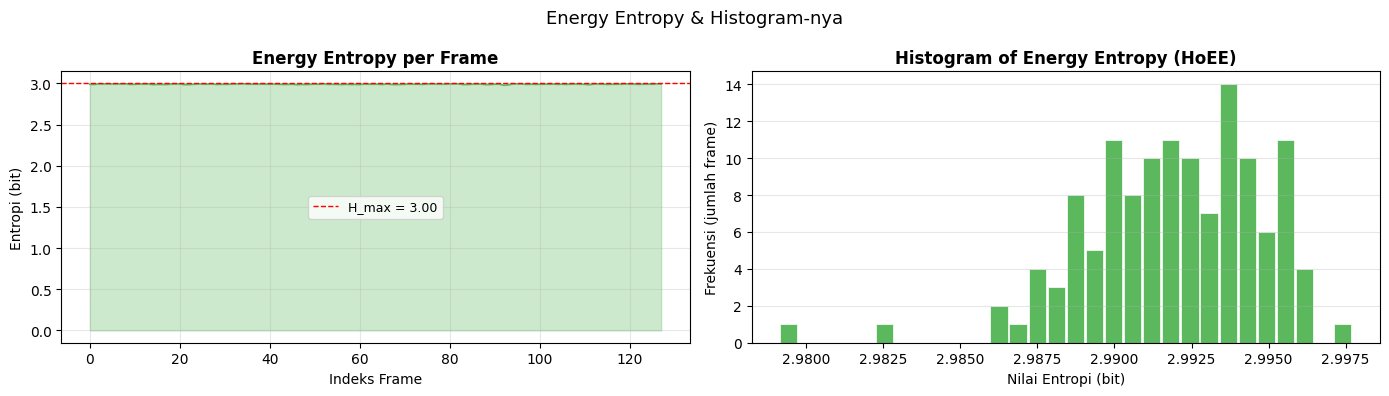

Histogram of Energy Entropy berhasil dihitung (30 bin).


In [20]:
# Visualisasi
ee_counts, ee_edges = manual_histogram(entropy_values.tolist(), N_BINS)
ee_centers = [(ee_edges[i] + ee_edges[i+1]) / 2 for i in range(N_BINS)]
ee_bw      = ee_edges[1] - ee_edges[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(entropy_values, color='#5CB85C', lw=1.2)
axes[0].fill_between(range(len(entropy_values)), entropy_values, alpha=0.3, color='#5CB85C')
axes[0].axhline(math.log2(N_SUBFRAMES), color='red', linestyle='--',
                lw=1.0, label=f'H_max = {math.log2(N_SUBFRAMES):.2f}')
axes[0].set_title('Energy Entropy per Frame', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Indeks Frame')
axes[0].set_ylabel('Entropi (bit)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].bar(ee_centers, ee_counts, width=ee_bw * 0.9,
            color='#5CB85C', edgecolor='white', linewidth=0.5)
axes[1].set_title('Histogram of Energy Entropy (HoEE)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Nilai Entropi (bit)')
axes[1].set_ylabel('Frekuensi (jumlah frame)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Energy Entropy & Histogram-nya', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Histogram of Energy Entropy berhasil dihitung ({N_BINS} bin).")

## 6. Ringkasan: Ketiga Histogram dalam Satu Gambar

Visualisasi perbandingan ketiga histogram sekaligus untuk melihat distribusi masing-masing fitur.

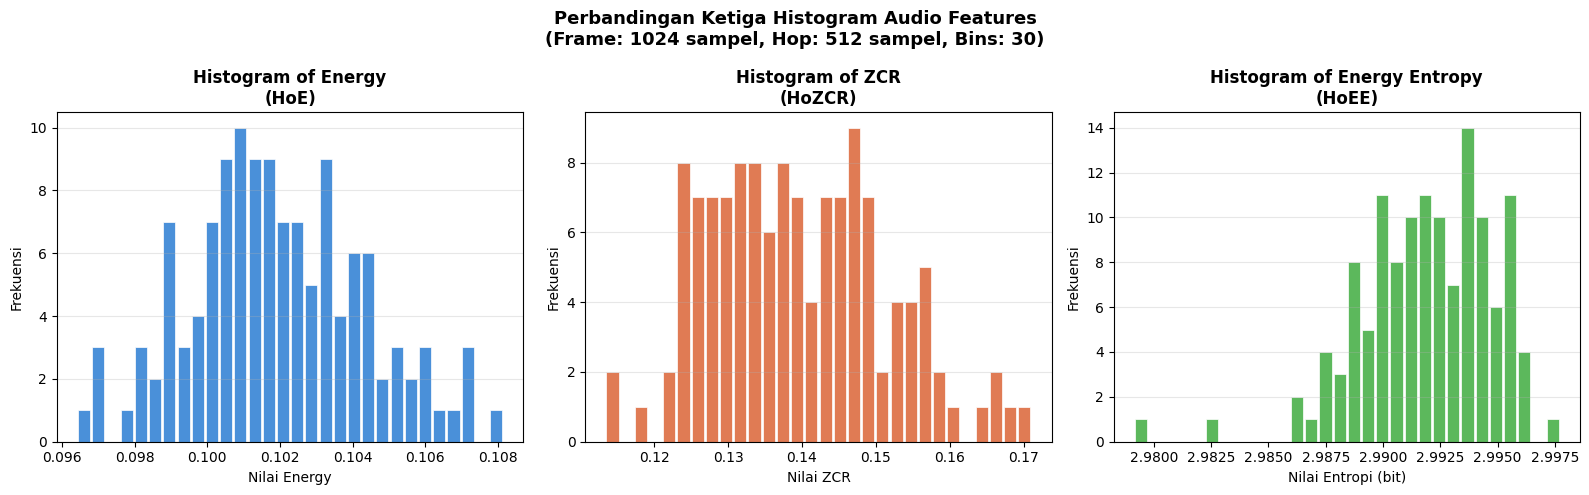

Plot tersimpan sebagai 'histogram_audio_features.png'


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# HoE
bw_e = energy_edges[1] - energy_edges[0]
axes[0].bar(bin_centers, energy_counts, width=bw_e * 0.85,
            color='#4A90D9', edgecolor='white', linewidth=0.5)
axes[0].set_title('Histogram of Energy\n(HoE)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Nilai Energy')
axes[0].set_ylabel('Frekuensi')
axes[0].grid(True, alpha=0.3, axis='y')

# HoZCR
axes[1].bar(zcr_centers, zcr_counts, width=zcr_bw * 0.85,
            color='#E07B54', edgecolor='white', linewidth=0.5)
axes[1].set_title('Histogram of ZCR\n(HoZCR)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Nilai ZCR')
axes[1].set_ylabel('Frekuensi')
axes[1].grid(True, alpha=0.3, axis='y')

# HoEE
axes[2].bar(ee_centers, ee_counts, width=ee_bw * 0.85,
            color='#5CB85C', edgecolor='white', linewidth=0.5)
axes[2].set_title('Histogram of Energy Entropy\n(HoEE)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Nilai Entropi (bit)')
axes[2].set_ylabel('Frekuensi')
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle(
    f'Perbandingan Ketiga Histogram Audio Features\n'
    f'(Frame: {FRAME_SIZE} sampel, Hop: {HOP_SIZE} sampel, Bins: {N_BINS})',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('histogram_audio_features.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot tersimpan sebagai 'histogram_audio_features.png'")


## 7. Rekap & Interpretasi

| Fitur | Rumus Inti | Makna Tinggi | Makna Rendah |
|---|---|---|---|
| **Energy** | $\frac{1}{N}\sum x^2$ | Sinyal keras/keras | Senyap/pelan |
| **ZCR** | $\frac{\text{#crossings}}{N-1}$ | Frekuensi tinggi, noise | Frekuensi rendah, vokal |
| **Energy Entropy** | $-\sum p_k \log_2 p_k$ | Distribusi energi merata (noise) | Energi terkonsentrasi (tonal) |

Ketiganya dihitung tanpa library audio, hanya loop Python murni + operasi matematika dasar.

In [22]:
print("REKAP IMPLEMENTASI")
print(f"  Panjang sinyal   : {N_SAMPLES} sampel ({DURATION}s)")
print(f"  Frame size       : {FRAME_SIZE} sampel")
print(f"  Hop size         : {HOP_SIZE} sampel")
print(f"  Jumlah frame     : {frames.shape[0]}")
print(f"  Jumlah bin       : {N_BINS}")
print(f"  Subframe (EE)    : {N_SUBFRAMES}")
print()
print("  Fitur        | Mean")
print(f"  Energy       | {energies.mean():.6f}")
print(f"  ZCR          | {zcr_values.mean():.6f}")
print(f"  EEntropy     | {entropy_values.mean():.6f} / {math.log2(N_SUBFRAMES):.4f} (max)")

REKAP IMPLEMENTASI
  Panjang sinyal   : 66150 sampel (3.0s)
  Frame size       : 1024 sampel
  Hop size         : 512 sampel
  Jumlah frame     : 128
  Jumlah bin       : 30
  Subframe (EE)    : 8

  Fitur        | Mean
  Energy       | 0.101912
  ZCR          | 0.139663
  EEntropy     | 2.991872 / 3.0000 (max)
